# Introdução

O objetivo do projeto é desenvolver um modelo preditivo capaz de prever se o índice IBOVESPA vai fechar em alta ou baixa no dia seguinte, com base em dados históricos do próprio índice.
Pelo material de análise se tratar de um valor que varia ao longo do tempo, será considerada a avaliação de uso de séries temporais para criação do modelo. Mas como o objetivo final é prever apenas se o valor vai subir ou descer, também será considerada a avaliação de uso de modelos de classificação

# Importação de Bibliotecas e Carregamento dos Dados

In [114]:
!pip install seaborn
!pip install -U scikit-learn
!pip install statsmodels
!pip install lazypredict
!pip install xgboost

In [69]:
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#from meteostat import Point, Daily
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import warnings
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [70]:
df = pd.read_csv("C:/Users/marce/Downloads/Dados Históricos - Ibovespa (9).csv", decimal=',')

In [71]:
df

,Data,Último,Abertura,Máxima,Mínima,Vol.,Var%
0,09.04.2026,195.129,192.206,195.514,192.206,"9,38B","1,52%"
1,08.04.2026,192.201,188.261,193.759,188.260,"12,59B","2,09%"
2,07.04.2026,188.259,188.162,188.259,185.885,"8,75B","0,05%"
3,06.04.2026,188.162,188.054,189.220,187.811,"5,70B","0,06%"
4,02.04.2026,188.052,187.923,189.251,185.214,"7,08B","0,05%"
...,...,...,...,...,...,...,...
4770,08.01.2007,42.830,42.249,42.926,42.144,"114,01M","1,38%"
4771,05.01.2007,42.245,44.019,44.081,42.160,"164,06M","-4,03%"
4772,04.01.2007,44.020,44.442,44.442,43.623,"86,58M","-0,96%"
4773,03.01.2007,44.445,45.379,45.379,44.284,"122,37M","-2,07%"


# Análise Exploratória dos Dados

In [72]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4775 entries, 0 to 4774
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Data      4775 non-null   str  
 1   Último    4775 non-null   str  
 2   Abertura  4775 non-null   str  
 3   Máxima    4775 non-null   str  
 4   Mínima    4775 non-null   str  
 5   Vol.      4774 non-null   str  
 6   Var%      4775 non-null   str  
dtypes: str(7)
memory usage: 261.3 KB


Transformando data em índice

In [73]:
df['Data'] = pd.to_datetime(df['Data'], format='%d.%m.%Y')
df = df.set_index(['Data']).sort_index()
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%
Data,,,,,,
2007-01-02,45.383,44.476,45.388,44.476,"75,56M","2,04%"
2007-01-03,44.445,45.379,45.379,44.284,"122,37M","-2,07%"
2007-01-04,44.020,44.442,44.442,43.623,"86,58M","-0,96%"
2007-01-05,42.245,44.019,44.081,42.160,"164,06M","-4,03%"
2007-01-08,42.830,42.249,42.926,42.144,"114,01M","1,38%"


In [74]:
print(f"Total de linhas: {len(df)}")
print(f"Nulos em Var%  : {df.isnull().sum()}")
print(f"\nOnde estão os nulos:")
print(df[df['Var%'].isnull()])

Total de linhas: 4775
Nulos em Var%  : Último      0
Abertura    0
Máxima      0
Mínima      0
Vol.        1
Var%        0
dtype: int64

Onde estão os nulos:
Empty DataFrame
Columns: [Último, Abertura, Máxima, Mínima, Vol., Var%]
Index: []


conversão de valores string para float

In [75]:

def convert_volume(vol_str):
    if isinstance(vol_str, float) or isinstance(vol_str, int):
        return vol_str
    vol_str = vol_str.replace('.', '').replace(',', '.') 
    if 'M' in vol_str:
        return float(vol_str.replace('M', '')) * 1_000_000
    elif 'B' in vol_str:
        return float(vol_str.replace('B', '')) * 1_000_000_000
    elif 'K' in vol_str: 
        return float(vol_str.replace('K', '')) * 1_000
    else:
        return float(vol_str)


def convert_percentage(var_str):
    if isinstance(var_str, float) or isinstance(var_str, int):
        return var_str
    return float(var_str.replace(',', '.').replace('%', ''))

def remove_dot(value):
    return float(value.replace('.', ''))

df['Vol.'] = df['Vol.'].apply(convert_volume)
df['Var%'] = df['Var%'].apply(convert_percentage)
df['Abertura'] = df['Abertura'].apply(remove_dot)
df['Último'] = df['Último'].apply(remove_dot)
df['Máxima'] = df['Máxima'].apply(remove_dot)
df['Mínima'] = df['Mínima'].apply(remove_dot)
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%
Data,,,,,,
2007-01-02,45383.0,44476.0,45388.0,44476.0,75560000.0,2.04
2007-01-03,44445.0,45379.0,45379.0,44284.0,122370000.0,-2.07
2007-01-04,44020.0,44442.0,44442.0,43623.0,86580000.0,-0.96
2007-01-05,42245.0,44019.0,44081.0,42160.0,164060000.0,-4.03
2007-01-08,42830.0,42249.0,42926.0,42144.0,114010000.0,1.38


criação da variável 'Subiu', que servirá como target do modelo

In [76]:
df['Subiu'] = np.where(df['Var%'] > 0, 1, 0)
df.head()

,Último,Abertura,Máxima,Mínima,Vol.,Var%,Subiu
Data,,,,,,,
2007-01-02,45383.0,44476.0,45388.0,44476.0,75560000.0,2.04,1
2007-01-03,44445.0,45379.0,45379.0,44284.0,122370000.0,-2.07,0
2007-01-04,44020.0,44442.0,44442.0,43623.0,86580000.0,-0.96,0
2007-01-05,42245.0,44019.0,44081.0,42160.0,164060000.0,-4.03,0
2007-01-08,42830.0,42249.0,42926.0,42144.0,114010000.0,1.38,1


# Tentativa de uso de séries temporais com ARIMA e SARIMA

## Análise Exploratória dos Dados Temporais

### Visualização dos Dados Originais

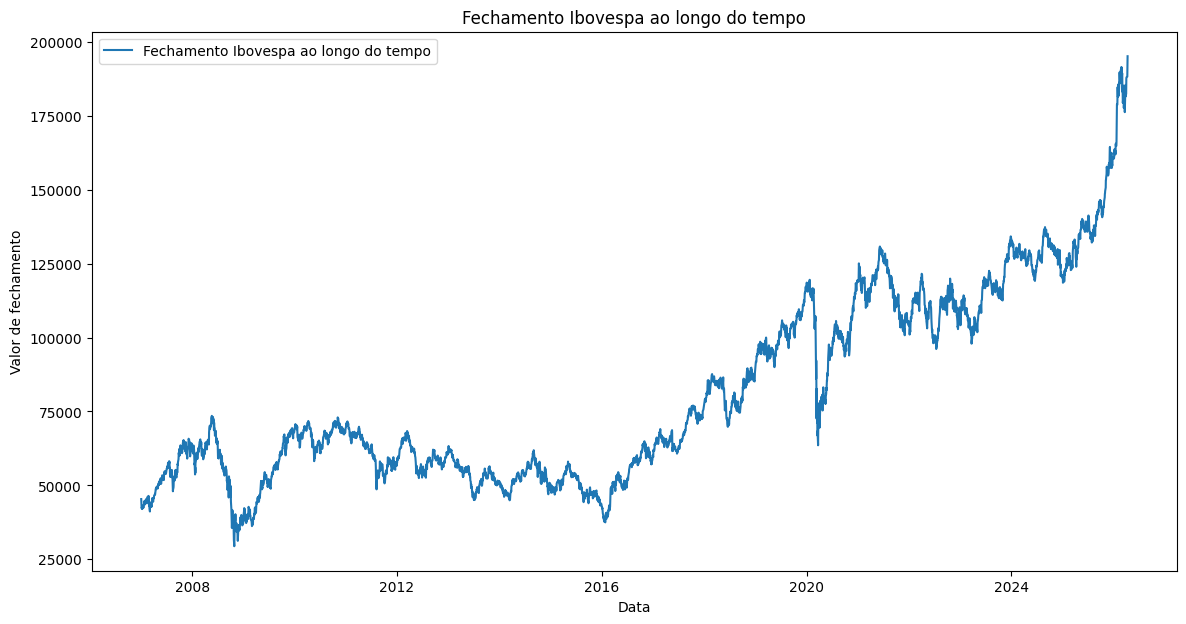

In [77]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df["Último"], label="Fechamento Ibovespa ao longo do tempo")
plt.title("Fechamento Ibovespa ao longo do tempo")
plt.xlabel("Data")
plt.ylabel("Valor de fechamento")
plt.legend()
plt.show()

<Axes: xlabel='Data'>

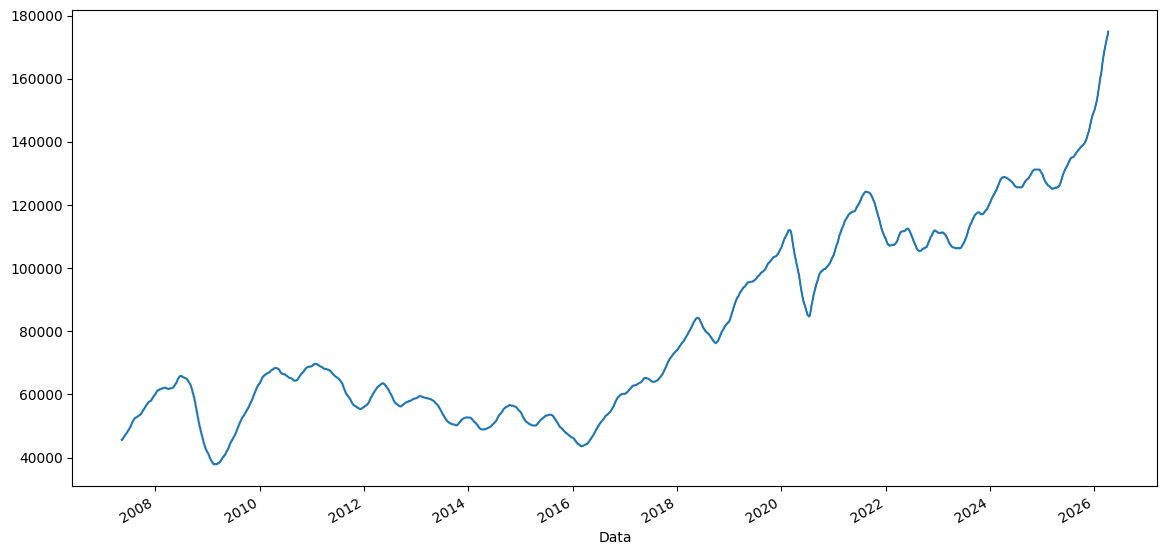

In [78]:
df["Último"].rolling(window=90).mean().plot(figsize=(14, 7))

### Decomposição da Série Temporal

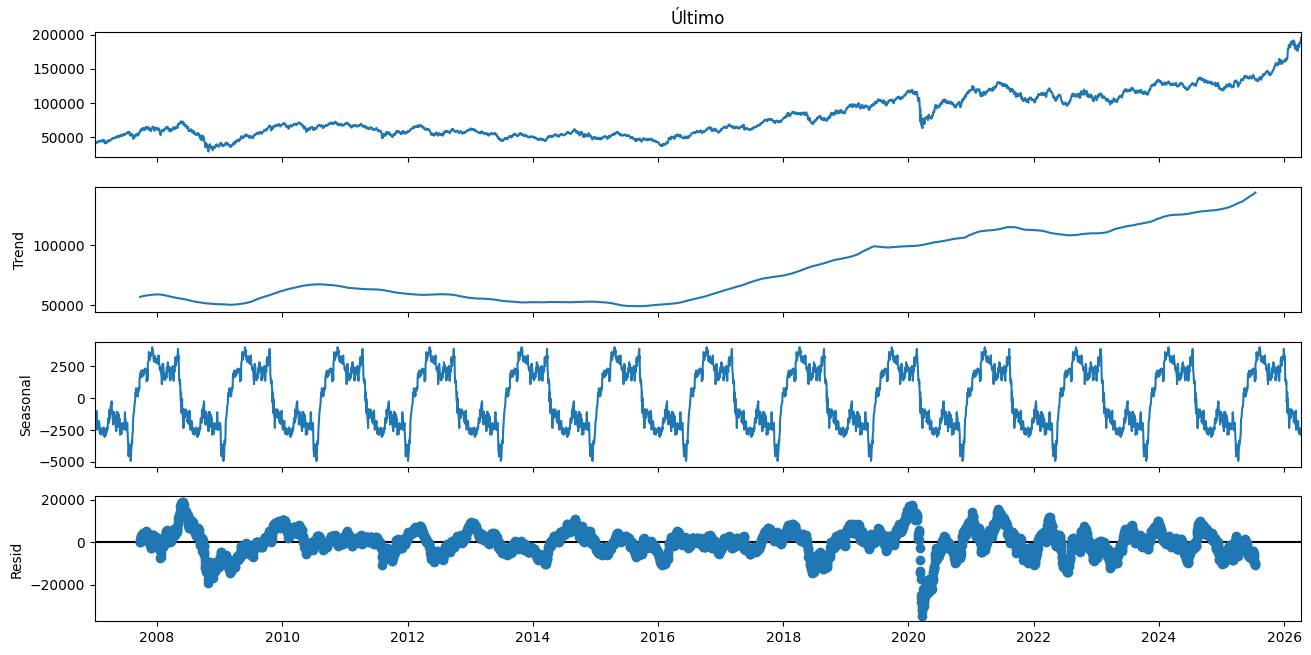

In [79]:
# Decomposição aditiva
resultado = seasonal_decompose(df["Último"], model="additive", period=365)

# Plot da decomposição
ax = resultado.plot()
ax.get_figure().set_size_inches(15, 7)

## Teste de Estacionariedade

In [80]:
# Teste ADF
resultado_adf = adfuller(df["Último"].dropna())
print(f"Estatística ADF: {resultado_adf[0]}")
print(f"Valor-p: {100*resultado_adf[1]:.2f}%")

# Interpretação
if resultado_adf[1] < 0.05:
    print("A série é estacionária.")
else:
    print("A série não é estacionária.")

Estatística ADF: 0.6237644358198375
Valor-p: 98.82%
A série não é estacionária.


## Estacionarização da Série Temporal

### Diferenciação de Primeira Ordem

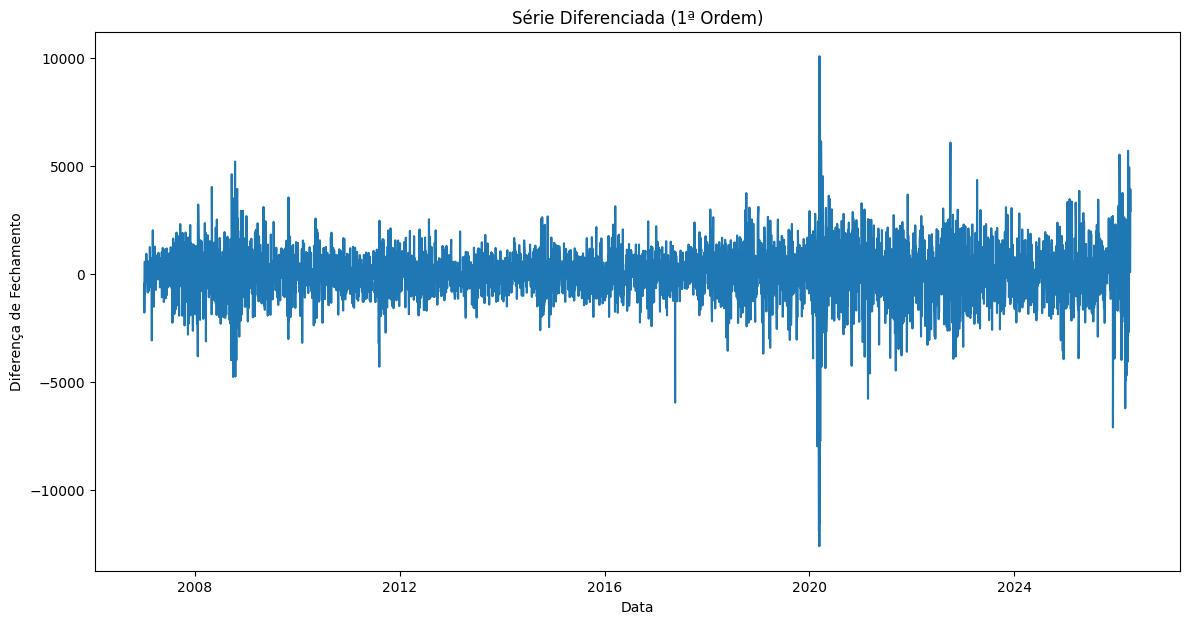

In [81]:
df_s = df.copy()

df_s["ÚltimoDiff"] = df_s["Último"] - df_s["Último"].shift(1)
df_s['ÚltimoDiff'] = df_s['ÚltimoDiff'].dropna()

# Plot da série diferenciada
plt.figure(figsize=(14, 7))
plt.plot(df_s.index, df_s['ÚltimoDiff'], label="Série Diferenciada (1ª Ordem)")
plt.title("Série Diferenciada (1ª Ordem)")
plt.xlabel("Data")
plt.ylabel("Diferença de Fechamento")
plt.show()

### Diferenciação Sazonal

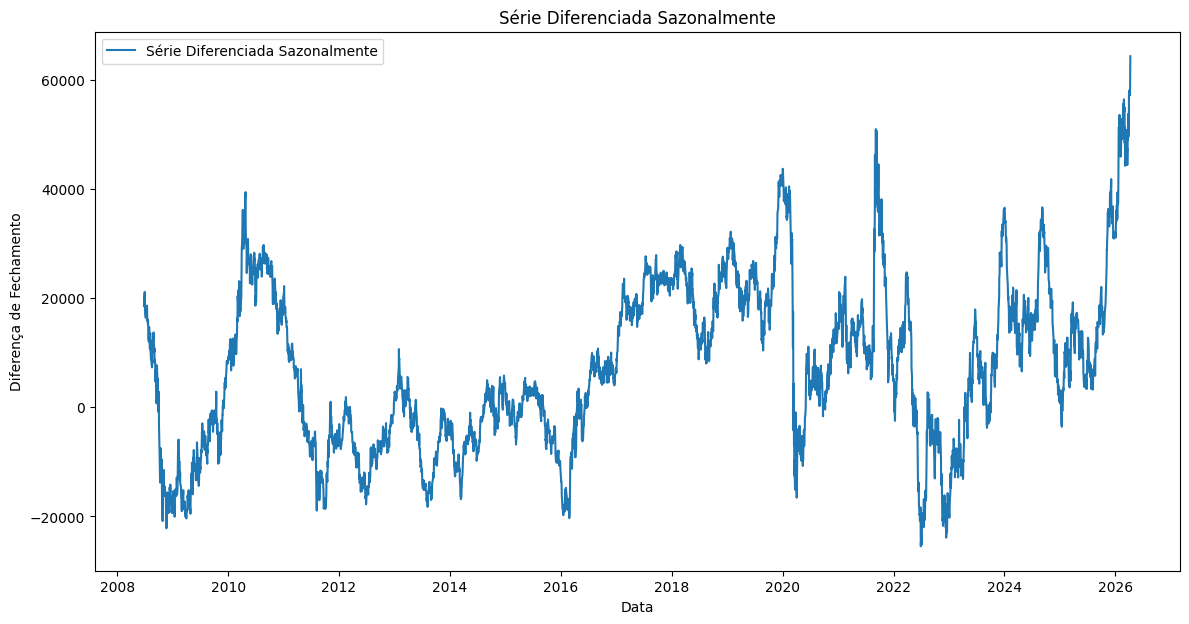

In [82]:

df_s["ÚltimoSeasonalDiff"] = df_s["Último"] - df_s["Último"].shift(365)
df_s["ÚltimoSeasonalDiff"] = df_s["ÚltimoSeasonalDiff"].dropna()

plt.figure(figsize=(14, 7))
plt.plot(df_s["ÚltimoSeasonalDiff"], label="Série Diferenciada Sazonalmente")
plt.title("Série Diferenciada Sazonalmente")
plt.xlabel("Data")
plt.ylabel("Diferença de Fechamento")
plt.legend()

Não evidencia sazonalidade anual, pois não oscila em torno de zero de forma constante

### Teste ADF na Série Transformada

In [83]:
# Teste ADF na série diferenciada
resultado_adf_diff = adfuller(df_s['ÚltimoDiff'].dropna())
print(f"Estatística ADF: {resultado_adf_diff[0]}")
print(f"Valor-p: {100*resultado_adf_diff[1]:.4}%")

# Interpretação
if resultado_adf_diff[1] < 0.05:
    print("A série diferenciada é estacionária.")
else:
    print("A série diferenciada não é estacionária.")

Estatística ADF: -18.552662614098963
Valor-p: 2.092e-28%
A série diferenciada é estacionária.


## Identificação dos Parâmetros do Modelo

### Funções de Autocorrelação (ACF) e Autocorrelação Parcial (PACF)

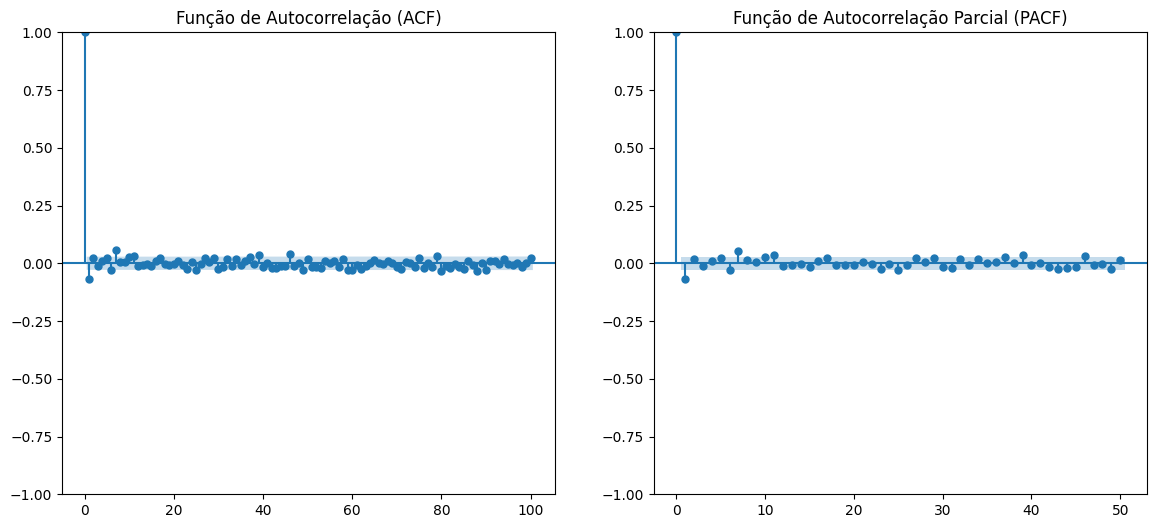

In [84]:
# Plot da ACF e PACF da série diferenciada
plt.figure(figsize=(14, 6))
plt.subplot(121)
plot_acf(df_s['ÚltimoDiff'].dropna(), ax=plt.gca(), lags=100)
plt.title("Função de Autocorrelação (ACF)")
plt.subplot(122)
plot_pacf(df_s['ÚltimoDiff'].dropna(), ax=plt.gca(), lags=50)
plt.title("Função de Autocorrelação Parcial (PACF)")
plt.show()

In [85]:
p=1 # ponto em que o gráfico PACF cruza a linha tracejada pela primeira vez
q=0 # ponto em que o gráfico ACF cruza a linha tracejada pela primeira vez
d=1 # quantas vezes a série foi diferenciada até se tornar estacionária

## Modelagem ARIMA

### Ajuste do Modelo ARIMA

In [86]:
serie = df_s['Último'].asfreq('B').iloc[:-30].sort_index()
ultimo_dia_serie = serie.index[-1] 
novas_datas_forecast = pd.date_range(start=ultimo_dia_serie, periods=31, freq='B')[1:]

In [87]:
model_arima = ARIMA(serie, order=(p, d, q))
resultado_arima = model_arima.fit()

print(resultado_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                 Último   No. Observations:                 4998
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -40343.508
Date:                Fri, 10 Apr 2026   AIC                          80691.016
Time:                        04:19:10   BIC                          80704.050
Sample:                    01-02-2007   HQIC                         80695.585
                         - 02-26-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0823      0.006    -14.101      0.000      -0.094      -0.071
sigma2      1.398e+06   1.18e+04    118.015      0.000    1.37e+06    1.42e+06
Ljung-Box (L1) (Q):                   0.00   Jarque-

### Diagnóstico dos Resíduos com Teste de Ljung-Box

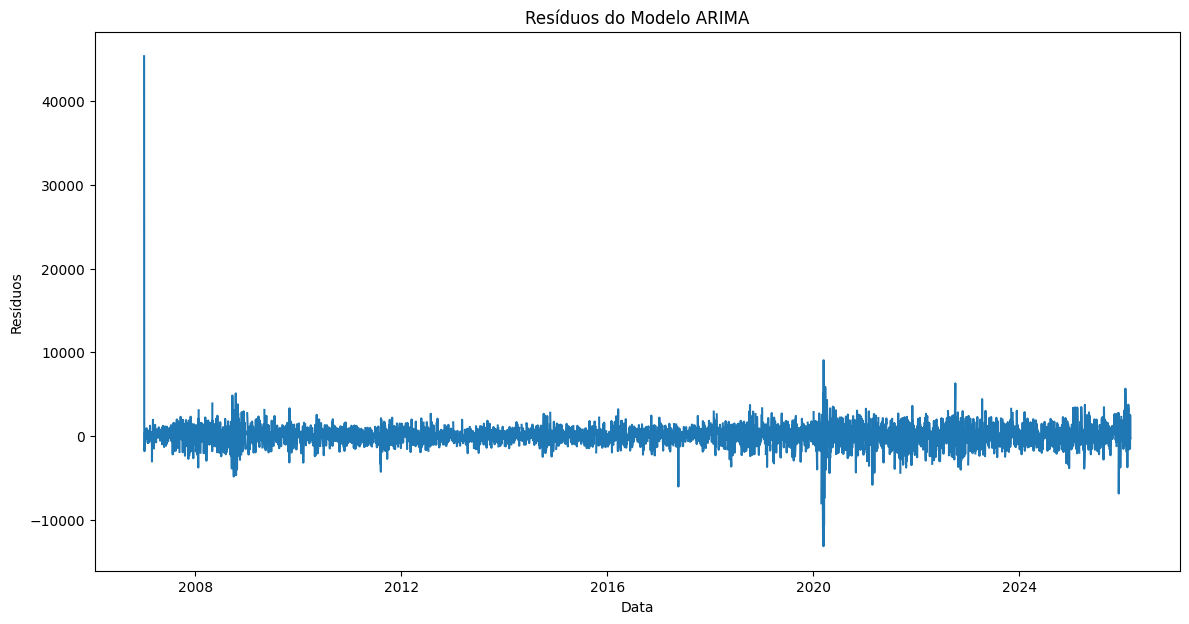

,lb_stat,lb_pvalue
10,20.500154,0.024862


In [88]:
# Resíduos do modelo ARIMA
resid_arima = resultado_arima.resid

# Plot dos resíduos
plt.figure(figsize=(14, 7))
plt.plot(resid_arima)
plt.title("Resíduos do Modelo ARIMA")
plt.xlabel("Data")
plt.ylabel("Resíduos")
plt.show()

# Teste de Ljung-Box
lb_test = acorr_ljungbox(resid_arima.dropna(), lags=[10], return_df=True)
lb_test

p_value extremamente baixo

### Previsão com ARIMA

2026-02-27    191024.914865
2026-03-02    191023.276015
2026-03-03    191023.410880
2026-03-04    191023.399782
2026-03-05    191023.400695
2026-03-06    191023.400620
2026-03-09    191023.400626
2026-03-10    191023.400626
2026-03-11    191023.400626
2026-03-12    191023.400626
2026-03-13    191023.400626
2026-03-16    191023.400626
2026-03-17    191023.400626
2026-03-18    191023.400626
2026-03-19    191023.400626
2026-03-20    191023.400626
2026-03-23    191023.400626
2026-03-24    191023.400626
2026-03-25    191023.400626
2026-03-26    191023.400626
2026-03-27    191023.400626
2026-03-30    191023.400626
2026-03-31    191023.400626
2026-04-01    191023.400626
2026-04-02    191023.400626
2026-04-03    191023.400626
2026-04-06    191023.400626
2026-04-07    191023.400626
2026-04-08    191023.400626
2026-04-09    191023.400626
Freq: B, Name: predicted_mean, dtype: float64


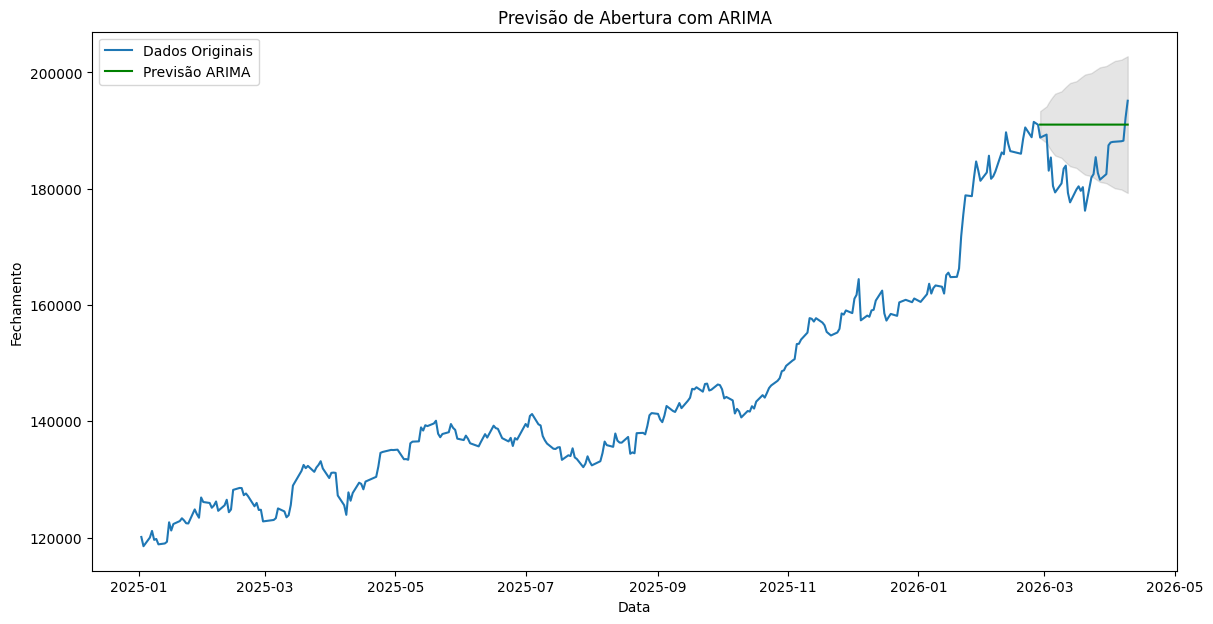

In [89]:
# Previsão dos próximos 30 dias
forecast_arima = resultado_arima.get_forecast(steps=30)
forecast_arima_mean = forecast_arima.predicted_mean
forecast_arima_conf_int = forecast_arima.conf_int()

forecast_arima_mean.index = novas_datas_forecast
forecast_arima_conf_int.index = novas_datas_forecast
print(forecast_arima_mean)
# Plot das previsões
plt.figure(figsize=(14, 7))
# Ajustando para mostrar apenas os dados históricos relevantes para a previsão
plt.plot(df_s['Último'].loc['2025-01':], label="Dados Originais")
plt.plot(
    forecast_arima_mean.index,
    forecast_arima_mean,
    color="green",
    label="Previsão ARIMA",
)
plt.fill_between(
    forecast_arima_conf_int.index,
    forecast_arima_conf_int.iloc[:, 0],
    forecast_arima_conf_int.iloc[:, 1],
    color="k",
    alpha=0.1,
)
plt.title("Previsão de Abertura com ARIMA")
plt.xlabel("Data")
plt.ylabel("Fechamento")
plt.legend()
plt.show()

O modelo resulta uma previsão quase sem oscilação, começando com variações muito suaves e se mantendo constante a partir de certo ponto. Além disso ser completamente diferente do que acontece na realidade, um modelo que se mantém constante não serve para prever subidas e descidas dos valores do fechamento.

## Modelagem SARIMA

### 8.1 Ajuste do Modelo SARIMA

Período Sazonal (s):

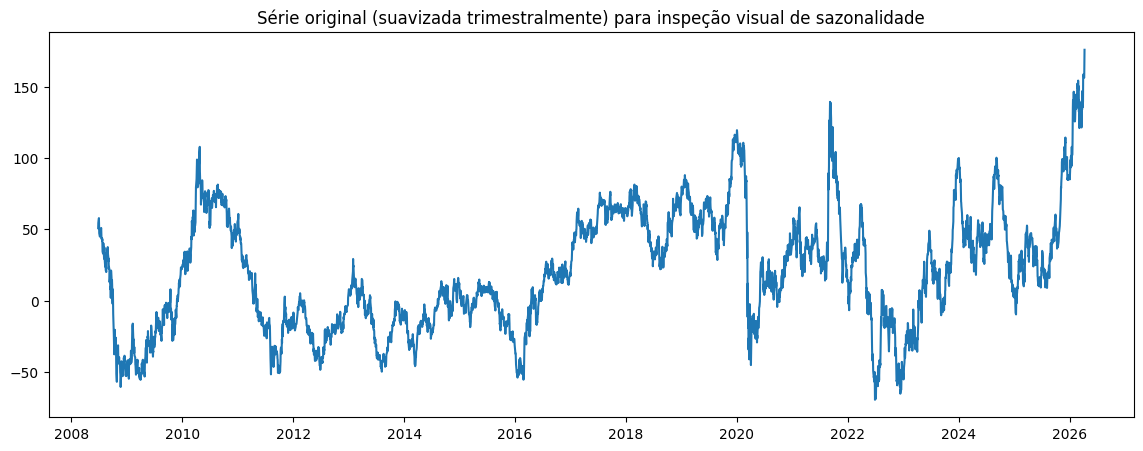

In [90]:
plt.figure(figsize=(14, 5))
plt.plot(df_s['ÚltimoDiff'].rolling(window=365).mean())
plt.title("Série original (suavizada trimestralmente) para inspeção visual de sazonalidade")
plt.show()

nenhuma sazonalidade visível, mas sem o aspecto de sazonalidade, o SARIMA funciona igual o ARIMA, então será assumida uma sazonalidade anual

In [104]:
s = 365
P = 0  
Q = 0  
D = 1
model_sarima = SARIMAX(
    serie,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False
)
resultado_sarima = model_sarima.fit()
# Resumo do modelo
print(resultado_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                              Último   No. Observations:                 4998
Model:             SARIMAX(1, 1, 0)x(0, 1, 0, 365)   Log Likelihood              -38948.747
Date:                             Fri, 10 Apr 2026   AIC                          77901.494
Time:                                     04:38:25   BIC                          77914.375
Sample:                                 01-02-2007   HQIC                         77906.026
                                      - 02-26-2026                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0733      0.008     -9.038      0.000      -0.089      -0.057
sigma2      2.665e+06   3.0

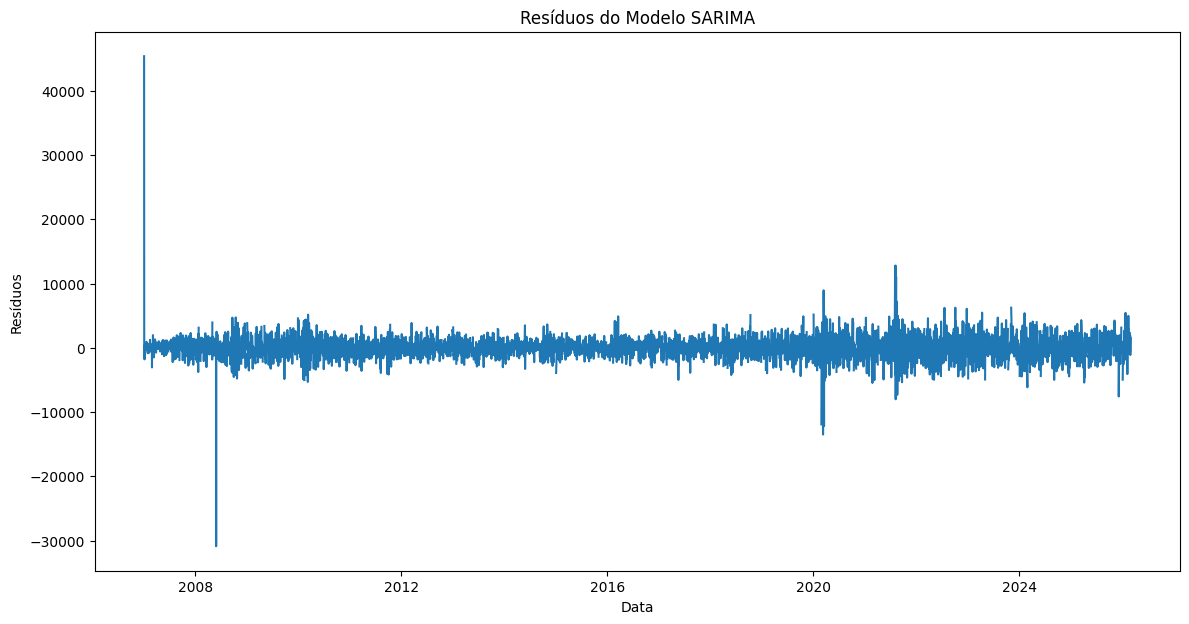

    lb_stat  lb_pvalue
10      NaN        NaN


In [110]:
# Resíduos do modelo SARIMA
resid_sarima = resultado_sarima.resid

# Plot dos resíduos
plt.figure(figsize=(14, 7))
plt.plot(resid_sarima)
plt.title("Resíduos do Modelo SARIMA")
plt.xlabel("Data")
plt.ylabel("Resíduos")
plt.show()

# Teste de Ljung-Box
lb_test_sarima = acorr_ljungbox(resid_sarima, lags=[10], return_df=True)
print(lb_test_sarima)

### **8.3 Previsão com o Modelo SARIMA**

2026-02-27    191007.650213
2026-03-02    191242.251695
2026-03-03    190735.621225
2026-03-04    189185.667437
2026-03-05    189576.664050
2026-03-06    189215.664298
2026-03-09    190228.664280
2026-03-10    190266.664282
2026-03-11    190973.664281
2026-03-12    190016.664281
2026-03-13    189722.664281
2026-03-16    189585.664281
2026-03-17    189174.664281
2026-03-18    188456.664281
2026-03-19    189290.664281
2026-03-20    189116.664281
2026-03-23    190436.664281
2026-03-24    189953.664281
2026-03-25    189862.664281
2026-03-26    188936.664281
2026-03-27    187344.664281
2026-03-30    189738.664281
2026-03-31    189884.664281
2026-04-01    189564.664281
2026-04-02    188905.664281
2026-04-03    187053.664281
2026-04-06    187097.664281
2026-04-07    186921.664281
2026-04-08    186957.664281
2026-04-09    187015.664281
Freq: B, Name: predicted_mean, dtype: float64


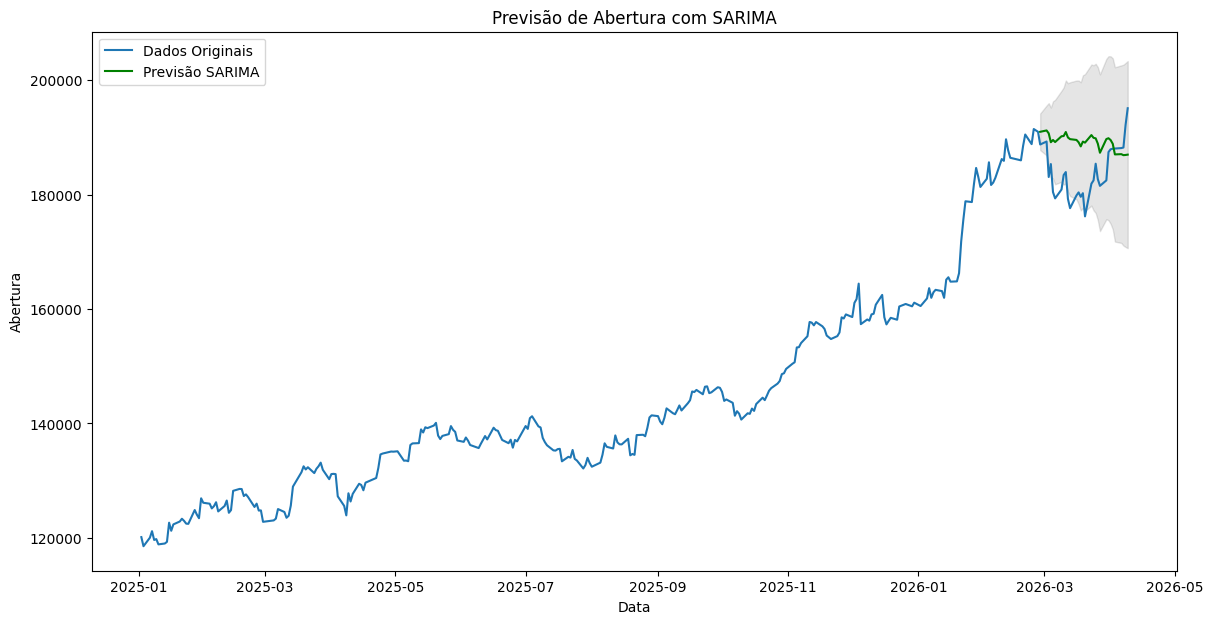

In [111]:
forecast_sarima = resultado_sarima.get_forecast(steps=30)
forecast_sarima_mean = forecast_sarima.predicted_mean
forecast_sarima_conf_int = forecast_sarima.conf_int()


ultimo_dia_serie = serie.index[-1] 
novas_datas_forecast = pd.date_range(start=ultimo_dia_serie, periods=30 + 1, freq='B')[1:]
forecast_sarima_mean.index = novas_datas_forecast
forecast_sarima_conf_int.index = novas_datas_forecast
print(forecast_sarima_mean)

plt.figure(figsize=(14, 7))

plt.plot(df_s['Último'].loc['2025-01':], label="Dados Originais")
plt.plot(
    forecast_sarima_mean.index,
    forecast_sarima_mean,
    color="green",
    label="Previsão SARIMA",
)
plt.fill_between(
    forecast_sarima_conf_int.index,
    forecast_sarima_conf_int.iloc[:, 0],
    forecast_sarima_conf_int.iloc[:, 1],
    color="k",
    alpha=0.1,
)
plt.title("Previsão de Abertura com SARIMA")
plt.xlabel("Data")
plt.ylabel("Abertura")
plt.legend()
plt.show()

In [94]:
forecast_df_s = pd.DataFrame({'predicted_mean': forecast_sarima_mean})
forecast_df_s['SubiuForecast'] = np.where(forecast_df_s['predicted_mean'] > forecast_df_s['predicted_mean'].shift(1), 1, 0)
forecast_df_s = forecast_df_s.join(df_s[['Último', 'Subiu']], how='left')
print(forecast_df_s)


            predicted_mean  SubiuForecast    Último  Subiu
2026-02-27   193494.701578              0  188787.0    0.0
2026-03-02   193266.779288              0  189307.0    1.0
2026-03-03   193023.235909              0  183105.0    0.0
2026-03-04   195513.095470              1  185366.0    1.0
2026-03-05   195285.157009              0  180464.0    0.0
2026-03-06   195041.615285              0  179365.0    0.0
2026-03-09   197531.474676              1  180915.0    1.0
2026-03-10   197303.536232              0  183447.0    1.0
2026-03-11   197059.994506              0  183969.0    1.0
2026-03-12   199549.853898              1  179284.0    0.0
2026-03-13   199321.915454              0  177653.0    0.0
2026-03-16   199078.373728              0  179875.0    1.0
2026-03-17   201568.233120              1  180410.0    1.0
2026-03-18   201340.294676              0  179640.0    0.0
2026-03-19   201096.752950              0  180271.0    1.0
2026-03-20   203586.612342              1  176219.0    0

In [113]:
forecast_df_s
acuracia = (forecast_df_s['SubiuForecast'] == forecast_df_s['Subiu']).mean() * 100
print(f"Acurácia: {acuracia:.1f}%")

Acurácia: 50.0%


Como esperado, o SARIMA não conseguiu fazer uma boa previsão devido a variação do valor de fechamento não ter uma sazonalidade evidente. Logo, utilizar séries temporais não é a melhor solução para o problema

# Utilizando modelos de Classificação

## Modelagem do df

Como a ideia é prever se a ibovespa vai subir ou descer no dia seguinte, não faz sentido a linha de um dia ter as colunas Último, Máxima, Mínima, Vol e Var% desse mesmo dia, pois essas informações só estariam disponíveis depois do dia acabar, o que causaria data leakage na previsao do modelo. Então elas serão substituídas pelos seus valores correspondentes do dia anterior

In [96]:
df_c = df.copy()

df_c['ÚltimoAnterior'] = df_c['Último'].shift(1)
df_c['MáximaAnterior'] = df_c['Máxima'].shift(1)
df_c['MínimaAnterior'] = df_c['Mínima'].shift(1)
df_c['Var%Anterior'] = df_c['Var%'].shift(1)
df_c['Vol.Anterior'] = df_c['Vol.'].shift(1)

df_c = df_c.iloc[1:]
df_c.drop(columns=['Máxima', 'Mínima', 'Vol.', 'Último', 'Var%'], inplace=True)

df_c.to_csv("out.csv", index=True)

df_c.head()

,Abertura,Subiu,ÚltimoAnterior,MáximaAnterior,MínimaAnterior,Var%Anterior,Vol.Anterior
Data,,,,,,,
2007-01-03,45379.0,0,45383.0,45388.0,44476.0,2.04,75560000.0
2007-01-04,44442.0,0,44445.0,45379.0,44284.0,-2.07,122370000.0
2007-01-05,44019.0,0,44020.0,44442.0,43623.0,-0.96,86580000.0
2007-01-08,42249.0,1,42245.0,44081.0,42160.0,-4.03,164060000.0
2007-01-09,42831.0,0,42830.0,42926.0,42144.0,1.38,114010000.0


Criação de features: Várias features foram criadas e testadas, e após vários testes essas foram escolhidas como as melhores

In [97]:
df_c["AberturaAnterior"] = df_c['Abertura'].shift(1)

df_c["Amplitude"] = (df_c["MáximaAnterior"] - df_c["MínimaAnterior"])/ df_c['MínimaAnterior']
df_c["AmplitudeLog"] = np.log((df_c["MáximaAnterior"] - df_c["MínimaAnterior"]))

df_c['Variação'] = (df_c['AberturaAnterior'] - df_c['ÚltimoAnterior']) / df_c['ÚltimoAnterior']
df_c['VariaçãoLog'] = np.log((df_c['ÚltimoAnterior'] / df_c['AberturaAnterior']))

df_c['ret1']      = np.log(df_c['ÚltimoAnterior']).diff(1)
df_c['ret5']      = np.log(df_c['ÚltimoAnterior']).diff(5)
df_c['ret21']     = np.log(df_c['ÚltimoAnterior']).diff(21)
df_c['Gap']        = (df_c['Abertura'] - df_c['ÚltimoAnterior']) / df_c['ÚltimoAnterior']


df_c = df_c.iloc[21:]

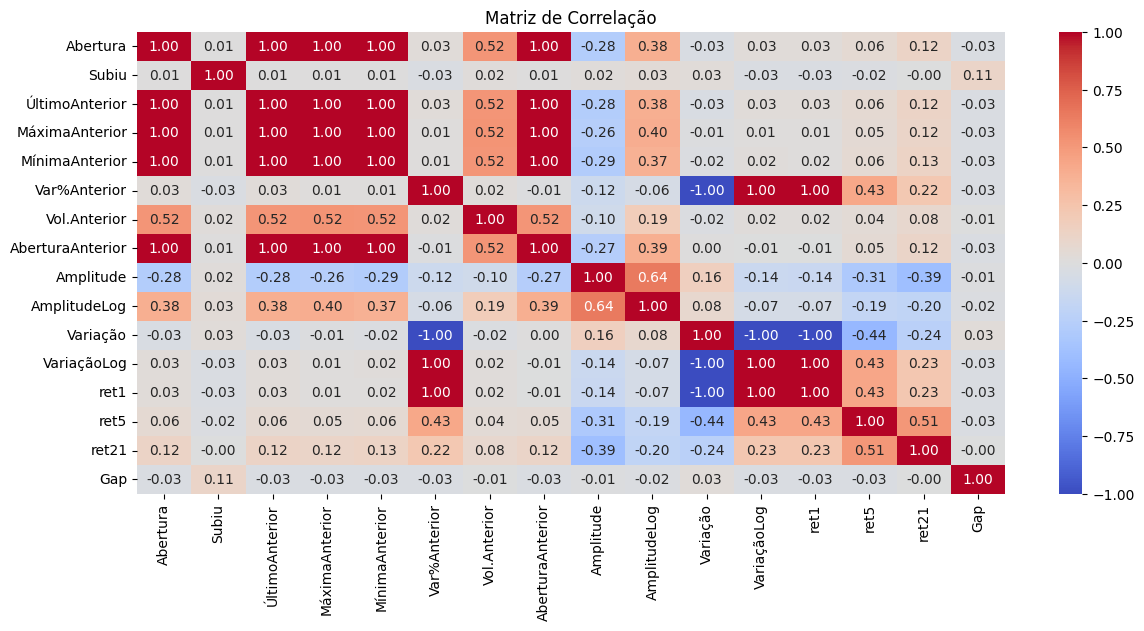

In [98]:
corr_matrix = df_c.corr(numeric_only=True)

# 2. Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Matriz de Correlação")
plt.show()

## Ajuste e teste dos modelos de classificação

Após a análise da matriz e testando diferentes combinações de features, essa foi a melhor configuração encontrada:

In [99]:
FEATURES = [
    'Amplitude', 
    'VariaçãoLog',
    'ret1',
    'Gap'
]


Para fazer a classificação foram testados os modelos: LogisticRegression, RandomForestClassifier, GradientBoostingClassifie e XGBClassifier. E testando vários parâmetros diferentes para cada, esses foram os melhores resultados enontrados:

In [101]:
X = df_c[FEATURES].values
y = df_c['Subiu'].values

N_TEST = 30
split  = len(X) - N_TEST

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

baseline = y_test.mean() * 100


modelos = {
    'Logística':         (LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced'), True),
    'Random Forest':     (RandomForestClassifier(n_estimators=200, max_depth=4,
                           min_samples_leaf=15, class_weight='balanced', random_state=42), False),
    'Gradient Boosting': (GradientBoostingClassifier(n_estimators=200, max_depth=3,
                           learning_rate=0.05, random_state=42), False),
    'XGBoost':           (XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                           random_state=42, eval_metric='logloss'), False),
}

print(f"Baseline: {baseline:.1f}%\n")
print(f"{'Modelo':<20} {'Acurácia':>9} {'Precision':>10} {'Recall':>7} {'F1':>7} {'AUC':>7}")
print("-"*65)

for nome, (modelo, scaled) in modelos.items():
    Xtr = X_train_s if scaled else X_train
    Xte = X_test_s  if scaled else X_test

    modelo.fit(Xtr, y_train)
    preds = modelo.predict(Xte)
    probs = modelo.predict_proba(Xte)[:, 1]

    acc  = accuracy_score(y_test, preds) *100
    prec = precision_score(y_test, preds) * 100
    rec  = recall_score(y_test, preds) * 100
    f1   = f1_score(y_test, preds) * 100
    auc  = roc_auc_score(y_test, probs)

    print(f"  {nome:<18} {acc:>8.1f}%  {prec:>8.1f}%  {rec:>6.1f}%  {f1:>6.1f}%  {auc:>6.3f}")


Baseline: 63.3%

Modelo                Acurácia  Precision  Recall      F1     AUC
-----------------------------------------------------------------
  Logística              63.3%      83.3%    52.6%    64.5%   0.684
  Random Forest          80.0%      93.3%    73.7%    82.4%   0.799
  Gradient Boosting      73.3%      78.9%    78.9%    78.9%   0.785
  XGBoost                73.3%      73.9%    89.5%    81.0%   0.823


O Random Forest foi o modelo com maior acurácia (80%), precisão (93.3%) e AUC (0.799).
Apesar do XGBoost ter recall maior, essa métrica não é prioritária para a escolha, sendo então o Random Forest o modelo escolhido

## Availiação do resultado do modelo Random Forest

              precision    recall  f1-score   support

         Cai       0.67      0.91      0.77        11
        Sobe       0.93      0.74      0.82        19

    accuracy                           0.80        30
   macro avg       0.80      0.82      0.80        30
weighted avg       0.84      0.80      0.80        30



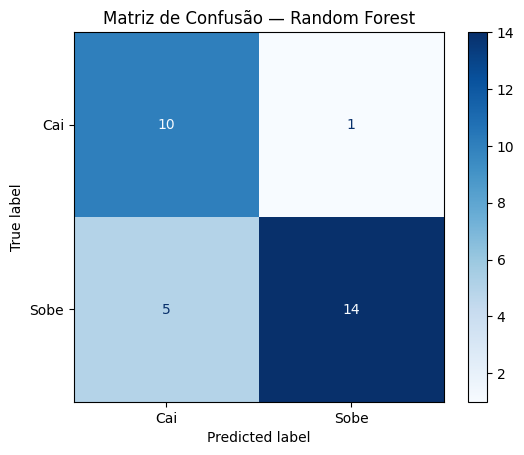

In [102]:
modelo_rf = modelos['Random Forest'][0]
preds_rf  = modelo_rf.predict(X_test)
print(classification_report(y_test, preds_rf, target_names=['Cai', 'Sobe']))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, preds_rf),
    display_labels=['Cai', 'Sobe']
).plot(cmap='Blues')
plt.title('Matriz de Confusão — Random Forest')
plt.show()

Com um f1-score de 0.82 para subida e 0.77 para descida e um macro average de 0.80, é notável um equilíbrio aceitável para ambas as direções, sem um viés excessivo.

In [109]:
acc_treino = accuracy_score(y_train, modelo_rf.predict(X_train)) * 100
acc_teste  = accuracy_score(y_test,  modelo_rf.predict(X_test))  * 100
print(f"Treino: {acc_treino:.1f}%")
print(f"Teste : {acc_teste:.1f}%")
print(f"Gap   : {acc_treino - acc_teste:.1f}pp")

Treino: 62.1%
Teste : 80.0%
Gap   : -17.9pp


A acurácia do treino foi menor que a de teste, o que evidencia que não teve overfitting.

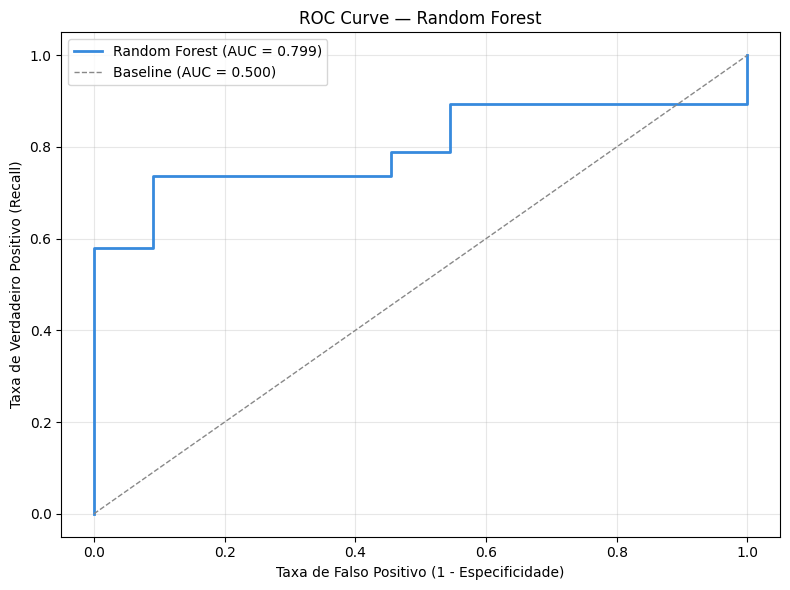

AUC Score: 0.799


In [103]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# probabilidades do Random Forest
probs = modelo_rf.predict_proba(X_test)[:, 1]

# AUC
auc = roc_auc_score(y_test, probs)

# curva ROC
fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#378ADD', lw=2, label=f'Random Forest (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='#888', lw=1, ls='--', label='Baseline (AUC = 0.500)')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Recall)')
plt.title('ROC Curve — Random Forest')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc:.3f}")

A curva está quase sempre acima da base line, indicando que o modelo aprendeu padrões reais

# Conclusão

Pelo material de análise se tratar de um valor que varia ao longo do tempo, foi considerado o de uso de séries temporais para criação do modelo. Porém o SARIMA resultou em uma previsão quase sem oscilação, começando com variações muito suaves e se mantendo constante a partir de certo ponto. Além disso ser completamente diferente do que acontece na realidade, um modelo que se mantém constante não serve para prever subidas e descidas dos valores do fechamento. E no caso do SARIMA, como não há sazonalidade clara na variação do fechamento da Ibovespa, ele não conseguiu realizar uma boa previsão de subida ou descida, com uma acurácia de apenas 50%. Logo, o uso de Séries Temporais não se mostrou eficiente.

Como o objetivo final do projeto é prever apenas se o valor de fechamento da ibovespa vai subir ou descer, também pôde ser feita uma análise por modelos de Classificação. Para garantir que nenhuma informação futura fosse utilizada na previsão, todas as features foram construídas com dados do pregão anterior (lagged), com exceção da Abertura do dia atual.

Para fazer a classificação em si foram usados os modelos LogisticRegression, RandomForestClassifier, GradientBoostingClassifie e XGBClassifier. E entre eles, o que se saiu melhor foi o RandomForestClassifier, com maior acurácia (80%), precisão (93.3%) e AUC (0.799).
Com um F1-score de 0.82 para subida, 0.77 para descida e macro average de 0.80, é notável um equilíbrio aceitável para ambas as direções, sem viés excessivo. A curva ROC acima do baseline indica que o modelo aprendeu padrões reais, e a ausência de overfitting é evidenciada pelo gap negativo entre treino (62%) e teste (80%), o Random Forest se mostrou o modelo mais eficiente para prever a direção do fechamento da Ibovespa nos últimos 30 dias.